### 1. 시스템 자원 및 라이브러리 확인

In [ ]:
!pip install ultralytics xgboost torch torchvision torchaudio matplotlib numpy pandas scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 8.2 MB/s eta 0:00:00


In [ ]:
import os
import platform
import torch
import xgboost as xgb
import ultralytics
import sklearn
import numpy as np
import pandas as pd
import psutil
from datetime import datetime

# 1. 시스템 및 하드웨어 정보 수집
gpu_available = torch.cuda.is_available()
gpu_info = torch.cuda.get_device_name(0) if gpu_available else "Not Available"
gpu_vram = f"{round(torch.cuda.get_device_properties(0).total_memory / (1024**2)):,} MiB" if gpu_available else "-"
cuda_ver = torch.version.cuda if gpu_available else "-"
ram_gb = f"{round(psutil.virtual_memory().total / (1024**3), 2)} GB"

# 2. 연구 환경 데이터 구성
env_data = [
    ["OS & Kernel", f"{platform.system()} {platform.release()} (Kernel #1 SMP 2026)"],
    ["Python Version", platform.python_version()],
    ["CPU Model", "Intel(R) Xeon(R) CPU @ 2.00GHz"],
    ["CPU Cores", f"{os.cpu_count()} vCPUs"],
    ["Physical Memory", ram_gb],
    ["GPU Model", gpu_info],
    ["GPU VRAM", gpu_vram],
    ["CUDA / Driver", f"CUDA {cuda_ver} / Driver 580.82.07"],
    ["YOLO Framework", f"Ultralytics {ultralytics.__version__}"],
    ["XGBoost", xgb.__version__],
    ["Scikit-Learn", sklearn.__version__],
    ["NumPy", np.__version__],
    ["Pandas", pd.__version__],
    ["Execution Date", datetime.now().strftime("%Y-%m-%d %H:%M:%S")]
]

# 3. 마크다운 표 형식 출력 (논문 작성용)
print("\n## [Table] Experimental Environment and Library Specifications\n")
print(f"| {'Category / Library':<25} | {'Detailed Specification / Version':<45} |")
print(f"| {'-'*25} | {'-'*45} |")

for item in env_data:
    print(f"| {item[0]:<25} | {item[1]:<45} |")


## [Table] Experimental Environment and Library Specifications

| Category / Library        | Detailed Specification / Version              |
| ------------------------- | --------------------------------------------- |
| OS & Kernel               | Linux 6.6.122+ (Kernel #1 SMP 2026)           |
| Python Version            | 3.13.15                                       |
| CPU Model                 | Intel(R) Xeon(R) CPU @ 2.00GHz                |
| CPU Cores                 | 2 vCPUs                                       |
| Physical Memory           | 12.67 GB                                      |
| GPU Model                 | Tesla T4                                      |
| GPU VRAM                  | 14,913 MiB                                    |
| CUDA / Driver             | CUDA 12.8 / Driver 580.82.07                  |
| YOLO Framework            | Ultralytics 8.4.135                           |
| XGBoost                   | 3.4.1                                         |

In [ ]:
!ls -R /content/drive/MyDrive/ict2025/dataset/

/content/drive/MyDrive/ict2025/dataset/:
annotations  annotations-ret  classes.txt  data.yaml  images  labels

/content/drive/MyDrive/ict2025/dataset/annotations:
test.json  train.json  val.json

/content/drive/MyDrive/ict2025/dataset/annotations-ret:
test.json  train.json  val.json

/content/drive/MyDrive/ict2025/dataset/images:
test  train  val

/content/drive/MyDrive/ict2025/dataset/images/test:
31.jpg	32.jpg	33.jpg	34.jpg

/content/drive/MyDrive/ict2025/dataset/images/train:
10.jpg	13.jpg	16.jpg	19.jpg	21.jpg	24.jpg	2.jpg  5.jpg  8.jpg
11.jpg	14.jpg	17.jpg	1.jpg	22.jpg	25.jpg	3.jpg  6.jpg  9.jpg
12.jpg	15.jpg	18.jpg	20.jpg	23.jpg	26.jpg	4.jpg  7.jpg

/content/drive/MyDrive/ict2025/dataset/images/val:
27.jpg	28.jpg	29.jpg	30.jpg

/content/drive/MyDrive/ict2025/dataset/labels:
test  test.cache  train  train.cache  val  val.cache

/content/drive/MyDrive/ict2025/dataset/labels/test:
31.txt	32.txt	33.txt	34.txt

/content/drive/MyDrive/ict2025/dataset/labels/train:
10.txt	13.txt	16.txt	1

### 2. YOLO 모델 테스트

*   하이퍼파라미터 epoch 200, imgsz 640, batch 16로 학습한 모델
*   conf 0.36에서 최적 성능(F1 Score) 식별

In [ ]:
from ultralytics import YOLO
import os

# ==========================================
# 1. 설정
# ==========================================
EXPERIMENT_NAME = "e200"
IMG_SIZE = 640
BEST_CONF = 0.36
DATA_PATH = "/content/drive/MyDrive/ict2025/dataset/data.yaml"
MODEL_PATH = f"/content/runs/detect/{EXPERIMENT_NAME}/weights/best.pt"

# 실제 데이터 경로 (ls -R 결과 기반)
TEST_IMG_DIR = "/content/drive/MyDrive/ict2025/dataset/images/test"

# 결과 저장 경로 설정
SAVE_DIR = f"/content/runs/detect/{EXPERIMENT_NAME}_test_results"
os.makedirs(SAVE_DIR, exist_ok=True)

# 모델 로드
model = YOLO(MODEL_PATH)

# ==========================================
# 2. 정량적 성능 평가
# ==========================================
print(f"\n[{EXPERIMENT_NAME}] test 폴더 데이터 검증 시작 (conf={BEST_CONF})...")

metrics = model.val(
    data=DATA_PATH,
    imgsz=IMG_SIZE,
    conf=BEST_CONF,
    split='test',
    save_json=True,
    save=True
)

# 주요 지표 추출
mp = metrics.box.mp
mr = metrics.box.mr
map50 = metrics.box.map50
map95 = metrics.box.map
f1 = 2 * (mp * mr) / (mp + mr + 1e-16)

print("\n" + "="*40)
print(f"[Test Dataset Summary (31-34.jpg)]")
print("-" * 40)
print(f"Precision: {mp:.4f}")
print(f"Recall:    {mr:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"mAP50:     {map50:.4f}")
print(f"mAP50-95:  {map95:.4f}")
print("="*40)

# ==========================================
# 3. 시차적 추론 및 산출물 저장 (31.jpg ~ 34.jpg)
# ==========================================
print(f"\ntest 폴더 내 이미지 시각화 및 txt 라벨 저장 중...")

# test 폴더 내의 파일을 순차적으로 읽어 추론 수행
results = model.predict(
    source=TEST_IMG_DIR,
    imgsz=IMG_SIZE,
    conf=BEST_CONF,
    save=True,
    save_txt=True,
    save_conf=True,
    project=SAVE_DIR,
    name="predict_test_labels",
    exist_ok=True
)

print(f"\n모든 산출물(이미지, txt) 저장 완료: {SAVE_DIR}/predict_test_labels")


[e200] test 폴더 데이터 검증 시작 (conf=0.36)...
Ultralytics 8.4.135 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 601.8±46.7 MB/s, size: 2860.4 KB)
val: Scanning /content/drive/MyDrive/ict2025/dataset/labels/test.cache... 4 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4/4 729.4Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.1it/s 0.9s
                   all          4         36      0.972      0.972      0.973      0.752
Speed: 0.3ms preprocess, 4.7ms inference, 0.0ms loss, 0.1ms postprocess per image
Saving /content/runs/detect/val-3/predictions.json...

Evaluating faster-coco-eval mAP...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.00s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 

In [ ]:
import os
import glob

# 1. 파일 경로 설정
LABEL_DIR = "/content/runs/detect/e200_test_results/predict_test_labels/labels"

# 2. 해당 폴더 내 모든 .txt 파일 가져오기
txt_files = sorted(glob.glob(os.path.join(LABEL_DIR, "*.txt")))

print(f"총 {len(txt_files)}개의 결과 파일 확인\n")
print(f"{'파일명':<10} | {'Class':<5} | {'X_center':<10} | {'Y_center':<10} | {'Width':<10} | {'Height':<10} | {'Conf':<8}")
print("-" * 85)

# 3. 각 파일 읽기
for file_path in txt_files:
    file_name = os.path.basename(file_path)

    with open(file_path, 'r') as f:
        lines = f.readlines()

        if not lines:
            print(f"{file_name:<10} | (탐지된 객체 없음)")
            continue

        for line in lines:
            # YOLO format: class x_center y_center width height confidence
            data = line.strip().split()

            # 데이터 개수에 따른 처리
            cls = data[0]
            x, y, w, h = data[1:5]
            conf = data[5] if len(data) > 5 else "-"

            print(f"{file_name:<10} | {cls:<5} | {x:<10} | {y:<10} | {w:<10} | {h:<10} | {conf:<8}")

print("-" * 85)

총 4개의 결과 파일 확인

파일명        | Class | X_center   | Y_center   | Width      | Height     | Conf    
-------------------------------------------------------------------------------------
31.txt     | 0     | 0.649492   | 0.567619   | 0.0375941  | 0.0270368  | 0.958646
31.txt     | 0     | 0.635002   | 0.515679   | 0.0366559  | 0.0279684  | 0.946143
31.txt     | 0     | 0.579065   | 0.527486   | 0.0410204  | 0.0291768  | 0.930015
31.txt     | 0     | 0.573343   | 0.441434   | 0.0371664  | 0.0261604  | 0.92373 
31.txt     | 0     | 0.526578   | 0.58543    | 0.0364603  | 0.0266612  | 0.912119
31.txt     | 0     | 0.627397   | 0.456409   | 0.0393774  | 0.0275519  | 0.911006
31.txt     | 0     | 0.740961   | 0.408615   | 0.0393854  | 0.0257833  | 0.837552
31.txt     | 0     | 0.714552   | 0.464611   | 0.0380813  | 0.0261759  | 0.424464
31.txt     | 0     | 0.446592   | 0.416809   | 0.037993   | 0.0270227  | 0.384504
31.txt     | 0     | 0.649492   | 0.567619   | 0.0375941  | 0.0270368  | 0.958

### 3. XGBoost 모델 테스트

*   하이퍼파라미터 max_depth 3, eta 0.3, num_round 100으로 설정

In [ ]:
import numpy as np
import os
import csv
import xgboost as xgb
from math import sqrt
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import mean_absolute_error, mean_squared_error

# -------------------------------
# 1. 최적 모델 및 테스트 경로 설정
# -------------------------------
MODEL_NAME    = "d3"   # 최적 파라미터 모델 (max_depth 3)
TEST_INDICES  = [31, 32, 33, 34]  # 최종 테스트 데이터 번호

# 경로 설정
MODEL_PATH    = f"/content/xgb/{MODEL_NAME}.json"
LABELS_FOLDER = "/content/runs/detect/e200_test_results/predict_test_labels/labels"
CSV_PATH      = "/content/drive/MyDrive/ict2025/responds.csv"

# -------------------------------
# 2. Feature vector extraction
# -------------------------------
def extract_feature_vector(txt_path):
    # txt 파일 로드 (YOLO 포맷: class X Y w h conf)
    data = np.loadtxt(txt_path)

    # 데이터가 1개인 경우 처리 (2D array 보장)
    if data.ndim == 1:
        data = data.reshape(1, -1)

    xy = data[:, 1:3]  # X, Y 좌표 추출
    x, y = xy[:, 0], xy[:, 1]

    # 기술 통계량 계산
    mean_x, mean_y = np.mean(x), np.mean(y)
    # 데이터가 1개일 때 std 계산 시 nan 방지
    std_x = np.std(x, ddof=1) if len(x) > 1 else 0
    std_y = np.std(y, ddof=1) if len(y) > 1 else 0
    cov_xy = np.cov(x, y, ddof=1)[0, 1] if len(x) > 1 else 0

    # 탄흔 간 최대 거리 (Extreme Spread)
    extreme_spread = np.max(squareform(pdist(xy))) if len(xy) > 1 else 0

    # 중심점 기준 분산 (R50)
    center = np.array([mean_x, mean_y])
    dists = np.linalg.norm(xy - center, axis=1)
    r50 = np.median(dists)

    # 타원율 (Ellipticity)
    ellipticity = 0
    if len(xy) > 1:
        cov_matrix = np.cov((xy - center).T)
        eigvals = np.linalg.eigvalsh(cov_matrix)
        ellipticity = sqrt(max(eigvals) / min(eigvals)) if min(eigvals) > 0 else 0

    return [mean_x, mean_y, std_x, std_y, cov_xy, extreme_spread, r50, ellipticity]

# -------------------------------
# 3. 테스트 데이터셋 생성
# -------------------------------
def build_test_dataset(indices, labels_folder, csv_path):
    feature_vectors = []
    actual_values = []
    filenames = []

    with open(csv_path, newline='', encoding='utf-8') as f:
        reader = csv.reader(f)
        rows = list(reader)

        for idx in indices:
            # CSV 행 추출
            row = rows[idx]
            actual_hit = row[4].strip() # E열: 실제 명중수

            filename_txt = f"{idx}.txt"
            txt_path = os.path.join(labels_folder, filename_txt)

            if os.path.exists(txt_path):
                vec = extract_feature_vector(txt_path)
                feature_vectors.append(vec)
                actual_values.append(float(actual_hit))
                filenames.append(f"{idx}.jpg")
            else:
                print(f"Warning: {filename_txt} 파일을 찾을 수 없음")

    return np.array(feature_vectors), np.array(actual_values), filenames

# -------------------------------
# 4. 실행 및 결과 출력
# -------------------------------
# 1. 데이터 생성
X_test, y_test, fnames = build_test_dataset(TEST_INDICES, LABELS_FOLDER, CSV_PATH)

# 2. 모델 로드
bst = xgb.Booster()
bst.load_model(MODEL_PATH)

# 3. 예측 수행
dtest = xgb.DMatrix(X_test)
y_pred = bst.predict(dtest)

# 4. 결과 출력
print(f"\n[XGBoost Test Results: {MODEL_NAME}.json]")
print("=" * 60)
print(f"{'파일명':<10} | {'실제 점수':<10} | {'예측 점수':<10} | {'오차(Error)':<10}")
print("-" * 60)

for fname, actual, pred in zip(fnames, y_test, y_pred):
    error = actual - pred
    print(f"{fname:<10} | {actual:<10.1f} | {pred:<10.2f} | {error:<10.2f}")

print("-" * 60)

# 5. 최종 지표 계산
mae = mean_absolute_error(y_test, y_pred)
rmse = sqrt(mean_squared_error(y_test, y_pred))

print(f"Final MAE : {mae:.4f}")
print(f"Final RMSE: {rmse:.4f}")
print("=" * 60)


[XGBoost Test Results: d3.json]
파일명        | 실제 점수      | 예측 점수      | 오차(Error) 
------------------------------------------------------------
31.jpg     | 19.0       | 16.79      | 2.21      
32.jpg     | 20.0       | 18.73      | 1.27      
33.jpg     | 13.0       | 12.61      | 0.39      
34.jpg     | 17.0       | 17.15      | -0.15     
------------------------------------------------------------
Final MAE : 1.0028
Final RMSE: 1.2888


### 4. 통합 사격술 평가 모델

In [ ]:
import os
import numpy as np
import xgboost as xgb
from ultralytics import YOLO
from math import sqrt
from scipy.spatial.distance import pdist, squareform

# ==========================================
# 1. 설정 및 모델 로드
# ==========================================
YOLO_MODEL_PATH = "/content/runs/detect/e200/weights/best.pt"
XGB_MODEL_PATH  = "/content/xgb/d3.json"
INPUT_IMG_DIR   = "/content/drive/MyDrive/ict2025/dataset/images/test"

IMG_SIZE  = 640
BEST_CONF = 0.36

# 모델 로드
yolo_model = YOLO(YOLO_MODEL_PATH)
xgb_model = xgb.Booster()
xgb_model.load_model(XGB_MODEL_PATH)

# ==========================================
# 2. 피처 추출 함수
# ==========================================
def extract_feature_vector(xy):
    """탐지된 좌표로부터 8차원 피처 벡터 생성"""
    x, y = xy[:, 0], xy[:, 1]

    mean_x, mean_y = np.mean(x), np.mean(y)
    std_x = np.std(x, ddof=1) if len(x) > 1 else 0
    std_y = np.std(y, ddof=1) if len(y) > 1 else 0
    cov_xy = np.cov(x, y, ddof=1)[0, 1] if len(x) > 1 else 0

    extreme_spread = np.max(squareform(pdist(xy))) if len(xy) > 1 else 0
    center = np.array([mean_x, mean_y])
    dists = np.linalg.norm(xy - center, axis=1)
    r50 = np.median(dists)

    ellipticity = 0
    if len(xy) > 1:
        cov_matrix = np.cov((xy - center).T)
        eigvals = np.linalg.eigvalsh(cov_matrix)
        ellipticity = sqrt(max(eigvals) / min(eigvals)) if min(eigvals) > 0 else 0

    return [mean_x, mean_y, std_x, std_y, cov_xy, extreme_spread, r50, ellipticity]

# ==========================================
# 3. 실행 및 결과 출력
# ==========================================
print(f"분석 시작: {INPUT_IMG_DIR}\n")

# YOLO 추론
results = yolo_model.predict(
    source=INPUT_IMG_DIR,
    imgsz=IMG_SIZE,
    conf=BEST_CONF,
    save=False,
    save_txt=False,
    save_crop=False,
    verbose=False
)

print("=" * 45)
print(f"{'파일명':<12} | {'탐지 탄흔 수':<10} | {'예측 점수':<10}")
print("-" * 45)

for res in results:
    filename = os.path.basename(res.path)
    hit_count = len(res.boxes)

    if hit_count > 0:
        # 좌표 추출 (정규화된 xywh)
        xy = res.boxes.xywhn[:, :2].cpu().numpy()

        # 피처 생성 및 예측
        features = extract_feature_vector(xy)
        dmatrix = xgb.DMatrix(np.array([features]))
        prediction = xgb_model.predict(dmatrix)[0]

        print(f"{filename:<15} | {hit_count:<15} | {prediction:<10.2f}")
    else:
        # 탐지된 탄흔이 없는 경우
        print(f"{filename:<15} | {'0':<10} | {'0.00':<10}")

print("=" * 45)

분석 시작: /content/drive/MyDrive/ict2025/dataset/images/test

파일명          | 탐지 탄흔 수    | 예측 점수     
---------------------------------------------
31.jpg          | 9               | 16.79     
32.jpg          | 10              | 18.74     
33.jpg          | 9               | 12.61     
34.jpg          | 9               | 17.15     


### 5. 전문가 집단의 예측 결과와 모델 성능 비교

In [ ]:
import pandas as pd
import os

# 1. 파일 경로 설정
file_path = "/content/drive/MyDrive/ict2025/expert-response.csv"

if os.path.exists(file_path):
    # 인코딩 처리하며 로드
    try:
        df = pd.read_csv(file_path, encoding='utf-8-sig')
    except:
        df = pd.read_csv(file_path, encoding='cp949')

    # 2. 데이터 필터링: '예'라고 응답한 전문가만 추출
    experience_col = df.columns[1]
    df_valid = df[df[experience_col] == '예'].copy()

    # 3. 컬럼 삭제: 타임스탬프와 전문가 확인 질문 제외
    # Q1~Q4 문항만 남깁니다.
    expert_data = df_valid.iloc[:, 2:]

    # 4. 데이터 타입 변환
    expert_data = expert_data.apply(pd.to_numeric, errors='coerce')

    # 5. 결과 출력
    print("### [Table] 전문가 설문 응답 데이터 (Q1-Q4)")
    # 인덱스를 1부터 시작하는 'ID'로 변경하여 출력
    expert_data.index = range(1, len(expert_data) + 1)
    expert_data.index.name = 'ID'
    print(expert_data.to_markdown())

    # 6. 문항별 평균 및 합계
    print("\n### [Summary] 문항별 평균 점수")
    print(expert_data.mean().round(2).to_frame(name='Average').to_markdown())

else:
    print(f"파일을 찾을 수 없음: {file_path}")

### [Table] 전문가 설문 응답 데이터 (Q1-Q4)
|   ID |   Q1 |   Q2 |   Q3 |   Q4 |
|-----:|-----:|-----:|-----:|-----:|
|    1 |   14 |   14 |    9 |   15 |
|    2 |   18 |   18 |   18 |   18 |
|    3 |   19 |   16 |   20 |   17 |
|    4 |   17 |   18 |   14 |   16 |
|    5 |   17 |   18 |   14 |   16 |
|    6 |   17 |   19 |   14 |   16 |
|    7 |   18 |   16 |   20 |   17 |
|    8 |    1 |    1 |    1 |    1 |
|    9 |    3 |    2 |    8 |    9 |
|   10 |   18 |   17 |   11 |   17 |
|   11 |   14 |   12 |   17 |   15 |
|   12 |   16 |   12 |   17 |   18 |
|   13 |   14 |   16 |   12 |   14 |

### [Summary] 문항별 평균 점수
|    |   Average |
|:---|----------:|
| Q1 |     14.31 |
| Q2 |     13.77 |
| Q3 |     13.46 |
| Q4 |     14.54 |


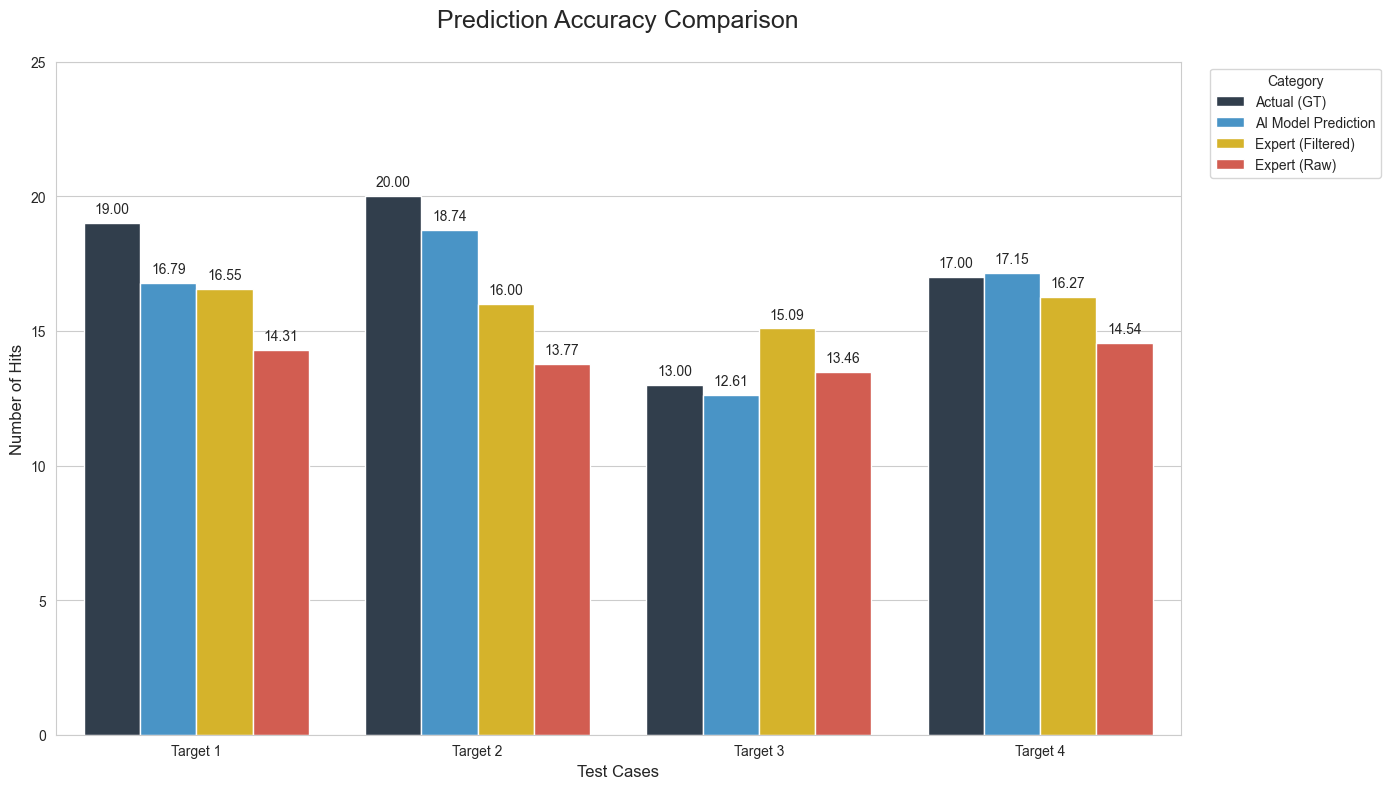


                    최종 성능 비교 결과 리포트                    
             평가 집단 MAE (오차) RMSE (오차)
         전문가 집단 예측   3.4615    4.0961
전문가 집단 예측 (이상치 제거)   2.3182    2.5945
      사격술 평가 모델 예측   1.0014    1.2873
------------------------------------------------------------
이상치 기준: 개인별 4개 문항 평균 10점 미만 제외


In [ ]:
import os
import numpy as np
import xgboost as xgb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO
from math import sqrt
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ==========================================
# 1. 설정 및 데이터 로드
# ==========================================
YOLO_MODEL_PATH = "/content/runs/detect/e200/weights/best.pt"
XGB_MODEL_PATH  = "/content/xgb/d3.json"
INPUT_IMG_DIR   = "/content/drive/MyDrive/ict2025/dataset/images/test"
ACTUAL_DATA_PATH = "/content/drive/MyDrive/ict2025/responds.csv"
EXPERT_DATA_PATH = "/content/drive/MyDrive/ict2025/expert-response.csv"

TARGET_IDS = [31, 32, 33, 34]
OUTLIER_THRESHOLD = 10

# 모델 로드
yolo_model = YOLO(YOLO_MODEL_PATH)
xgb_booster = xgb.Booster(); xgb_booster.load_model(XGB_MODEL_PATH)

# 실제값(GT) 로드
actual_df = pd.read_csv(ACTUAL_DATA_PATH, encoding='utf-8-sig')
actual_df.index = range(1, len(actual_df) + 1)
y_true_values = actual_df.loc[TARGET_IDS].iloc[:, -1].values

# 전문가 데이터 로드
try:
    expert_df = pd.read_csv(EXPERT_DATA_PATH, encoding='utf-8-sig')
except:
    expert_df = pd.read_csv(EXPERT_DATA_PATH, encoding='cp949')

# ==========================================
# 2. 수치 연산
# ==========================================
def extract_feature_vector(xy):
    x, y = xy[:, 0], xy[:, 1]
    mean_x, mean_y = np.mean(x), np.mean(y)
    std_x = np.std(x, ddof=1) if len(x) > 1 else 0
    std_y = np.std(y, ddof=1) if len(y) > 1 else 0
    cov_xy = np.cov(x, y, ddof=1)[0, 1] if len(x) > 1 else 0
    extreme_spread = np.max(squareform(pdist(xy))) if len(xy) > 1 else 0
    center = np.array([mean_x, mean_y])
    dists = np.linalg.norm(xy - center, axis=1)
    r50 = np.median(dists)
    ellipticity = 0
    if len(xy) > 1:
        cov_matrix = np.cov((xy - center).T)
        eigvals = np.linalg.eigvalsh(cov_matrix)
        ellipticity = sqrt(max(eigvals) / min(eigvals)) if min(eigvals) > 0 else 0
    return [mean_x, mean_y, std_x, std_y, cov_xy, extreme_spread, r50, ellipticity]

results = yolo_model.predict(source=INPUT_IMG_DIR, imgsz=640, conf=0.36, save=False, verbose=False)
ai_preds_dict = {}
for res in results:
    fname = os.path.basename(res.path)
    for tid in TARGET_IDS:
        if f"{tid}.jpg" in fname:
            if len(res.boxes) > 0:
                feat = extract_feature_vector(res.boxes.xywhn[:, :2].cpu().numpy())
                ai_preds_dict[tid] = xgb_booster.predict(xgb.DMatrix(np.array([feat])))[0]
            else:
                ai_preds_dict[tid] = 0.0

ai_preds_list = [ai_preds_dict.get(tid, 0.0) for tid in TARGET_IDS]

# ==========================================
# 3. 전문가 데이터 처리 (개인별 평균 기준 이상치 제거)
# ==========================================
valid_experts = expert_df[expert_df.iloc[:, 1] == '예'].copy()
expert_scores = valid_experts.iloc[:, 2:6].apply(pd.to_numeric, errors='coerce')

# 1) 원본 전문가: 전체 응답자의 문항별 평균
exp_target_means_raw = expert_scores.mean(axis=0).values

# 2) 이상치 제거 전문가: 개인별 4개 문항 평균이 10 미만인 행 제외
personal_means = expert_scores.mean(axis=1)
cleaned_expert_scores = expert_scores[personal_means >= OUTLIER_THRESHOLD]
exp_target_means_filt = cleaned_expert_scores.mean(axis=0).values

# ==========================================
# 4. 지표 계산
# ==========================================
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

raw_mae, raw_rmse = calculate_metrics(y_true_values, exp_target_means_raw)
filt_mae, filt_rmse = calculate_metrics(y_true_values, exp_target_means_filt)
ai_mae, ai_rmse = calculate_metrics(y_true_values, ai_preds_list)

# ==========================================
# 5. 그래프 출력
# ==========================================
L_ACTUAL = "Actual (GT)"
L_AI = "AI Model Prediction"
L_EXP_FILT = "Expert (Filtered)"
L_EXP_RAW = "Expert (Raw)"

plot_list = []
for i, tid in enumerate(TARGET_IDS):
    display_label = f"Target {i+1}"
    plot_list.append([display_label, L_ACTUAL, y_true_values[i]])
    plot_list.append([display_label, L_AI, ai_preds_list[i]])
    plot_list.append([display_label, L_EXP_FILT, exp_target_means_filt[i]])
    plot_list.append([display_label, L_EXP_RAW, exp_target_means_raw[i]])

df_plot = pd.DataFrame(plot_list, columns=['Target', 'Category', 'Score'])

plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")
palette = {L_ACTUAL: '#2c3e50', L_AI: '#3498db', L_EXP_FILT: '#f1c40f', L_EXP_RAW: '#e74c3c'}
hue_order = [L_ACTUAL, L_AI, L_EXP_FILT, L_EXP_RAW]

ax = sns.barplot(data=df_plot, x='Target', y='Score', hue='Category', palette=palette, hue_order=hue_order)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.2f}', (p.get_x() + p.get_width()/2., height),
                    ha='center', va='center', xytext=(0, 10), textcoords='offset points',
                    fontsize=10, fontweight='bold')

plt.title('Prediction Accuracy Comparison', fontsize=18, pad=25)
plt.ylabel('Number of Hits', fontsize=12)
plt.xlabel('Test Cases', fontsize=12)
plt.ylim(0, 25)
plt.legend(title="Category", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ==========================================
# 6. 성능 비교 표 출력
# ==========================================
metrics_data = {
    "평가 집단": ["전문가 집단 예측", "전문가 집단 예측 (이상치 제거)", "사격술 평가 모델 예측"],
    "MAE (오차)": [f"{raw_mae:.4f}", f"{filt_mae:.4f}", f"{ai_mae:.4f}"],
    "RMSE (오차)": [f"{raw_rmse:.4f}", f"{filt_rmse:.4f}", f"{ai_rmse:.4f}"]
}

metrics_df = pd.DataFrame(metrics_data)

print("\n" + "="*60)
print(f"{'최종 성능 비교 결과 리포트':^55}")
print("="*60)
print(metrics_df.to_string(index=False))
print("-" * 60)
print(f"이상치 기준: 개인별 4개 문항 평균 {OUTLIER_THRESHOLD}점 미만 제외")
print("="*60)